e# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [30]:
import pandas as pd

df = pd.read_csv("Indoor_Plant_Health_and_Growth_Factors.csv")

print(df.head())
print(df.shape)
print(df.columns)


                 Plant_ID  Height_cm  Leaf_Count  New_Growth_Count  \
0  Sansevieria cylindrica      17.39          17                 8   
1               Aloe vera       9.84          31                 9   
2            Ficus lyrata      19.82          40                 8   
3      Monstera deliciosa      37.08          11                 1   
4            Ficus lyrata       2.96          26                 3   

       Health_Notes  Watering_Amount_ml  Watering_Frequency_days  \
0  Yellowing leaves                 205                        3   
1               NaN                 191                        1   
2    Brittle leaves                 477                        5   
3           New bud                 207                        1   
4           Wilting                 465                        2   

                   Sunlight_Exposure  Room_Temperature_C  Humidity_%  \
0              3h direct morning sun                21.7        77.5   
1              3h direct m

Checking the data types

In [31]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Plant_ID                 1000 non-null   str    
 1   Height_cm                1000 non-null   float64
 2   Leaf_Count               1000 non-null   int64  
 3   New_Growth_Count         1000 non-null   int64  
 4   Health_Notes             882 non-null    str    
 5   Watering_Amount_ml       1000 non-null   int64  
 6   Watering_Frequency_days  1000 non-null   int64  
 7   Sunlight_Exposure        1000 non-null   str    
 8   Room_Temperature_C       1000 non-null   float64
 9   Humidity_%               1000 non-null   float64
 10  Fertilizer_Type          805 non-null    str    
 11  Fertilizer_Amount_ml     1000 non-null   int64  
 12  Pest_Presence            798 non-null    str    
 13  Pest_Severity            758 non-null    str    
 14  Soil_Moisture_%          1000 non-nu

In [32]:
print(df.isnull().sum())

Plant_ID                     0
Height_cm                    0
Leaf_Count                   0
New_Growth_Count             0
Health_Notes               118
Watering_Amount_ml           0
Watering_Frequency_days      0
Sunlight_Exposure            0
Room_Temperature_C           0
Humidity_%                   0
Fertilizer_Type            195
Fertilizer_Amount_ml         0
Pest_Presence              202
Pest_Severity              242
Soil_Moisture_%              0
Soil_Type                    0
Health_Score                 0
dtype: int64


I belive that stuff about pests, fertilizer and health notes are quite out of scope so i will be droping them

In [33]:
columns_to_drop = [
    "Health_Notes",
    "Fertilizer_Type",
    "Fertilizer_Amount_ml",
    "Pest_Presence",
    "Pest_Severity"
]


In [34]:
df_clean = df.drop(columns=columns_to_drop)

print(df_clean.head())
print(df_clean.info())
print(df_clean.isnull().sum())


                 Plant_ID  Height_cm  Leaf_Count  New_Growth_Count  \
0  Sansevieria cylindrica      17.39          17                 8   
1               Aloe vera       9.84          31                 9   
2            Ficus lyrata      19.82          40                 8   
3      Monstera deliciosa      37.08          11                 1   
4            Ficus lyrata       2.96          26                 3   

   Watering_Amount_ml  Watering_Frequency_days  \
0                 205                        3   
1                 191                        1   
2                 477                        5   
3                 207                        1   
4                 465                        2   

                   Sunlight_Exposure  Room_Temperature_C  Humidity_%  \
0              3h direct morning sun                21.7        77.5   
1              3h direct morning sun                22.6        68.9   
2             Indirect light all day                17.2      

In [35]:
print(df_clean.describe(include="all"))
print("Duplicate rows:", df_clean.duplicated().sum())
categorical_columns = [
    "Plant_ID",
    "Sunlight_Exposure",
    "Soil_Type"
]

for col in categorical_columns:
    print("\n", col)
    print(df_clean[col].value_counts())

                    Plant_ID    Height_cm   Leaf_Count  New_Growth_Count  \
count                   1000  1000.000000  1000.000000       1000.000000   
unique                    20          NaN          NaN               NaN   
top     Dracaena trifasciata          NaN          NaN               NaN   
freq                      59          NaN          NaN               NaN   
mean                     NaN    25.723450    27.038000          4.520000   
std                      NaN    10.448949    12.743585          2.844942   
min                      NaN    -4.140000     5.000000          0.000000   
25%                      NaN    19.030000    16.000000          2.000000   
50%                      NaN    25.965000    26.000000          5.000000   
75%                      NaN    32.627500    38.000000          7.000000   
max                      NaN    57.600000    49.000000          9.000000   

        Watering_Amount_ml  Watering_Frequency_days      Sunlight_Exposure  \
count    

In [36]:
numeric_columns = [
    "Height_cm",
    "Leaf_Count",
    "New_Growth_Count",
    "Watering_Amount_ml",
    "Watering_Frequency_days",
    "Room_Temperature_C",
    "Humidity_%",
    "Soil_Moisture_%",
    "Health_Score"
]

for col in numeric_columns:
    print("\n", col)
    print("min:", df_clean[col].min())
    print("max:", df_clean[col].max())
    print("mean:", df_clean[col].mean())


 Height_cm
min: -4.14
max: 57.6
mean: 25.723449999999996

 Leaf_Count
min: 5
max: 49
mean: 27.038

 New_Growth_Count
min: 0
max: 9
mean: 4.52

 Watering_Amount_ml
min: 51
max: 499
mean: 279.337

 Watering_Frequency_days
min: 1
max: 6
mean: 3.424

 Room_Temperature_C
min: 14.3
max: 34.6
mean: 23.947599999999998

 Humidity_%
min: 30.0
max: 80.0
mean: 54.707300000000004

 Soil_Moisture_%
min: 10.1
max: 59.9
mean: 34.728699999999996

 Health_Score
min: 1
max: 5
mean: 3.04


 hmmmm Height_cm
min: -4.14 this is weird minus height on plant
could be that the leafe died or smthing but i will jsut remove it bc its weird outlier

In [37]:
bad_height_rows = df_clean[df_clean["Height_cm"] <= 0]

print("Bad height rows:", len(bad_height_rows))
print(bad_height_rows)

Bad height rows: 8
                   Plant_ID  Height_cm  Leaf_Count  New_Growth_Count  \
16                Aloe vera      -2.60          24                 3   
146            Ficus lyrata      -0.02          34                 2   
150   Dieffenbachia seguine      -0.17          30                 5   
372            Ficus lyrata      -0.23          43                 6   
576  Zamioculcas zamiifolia      -4.02          32                 7   
778        Begonia maculata      -3.20          14                 6   
819        Begonia maculata      -2.02          19                 2   
937               Aloe vera      -4.14          16                 9   

     Watering_Amount_ml  Watering_Frequency_days  \
16                  339                        1   
146                 300                        2   
150                 271                        1   
372                 140                        1   
576                 277                        2   
778                 

so its only 8 rows. i will sacrifice them

In [38]:
df_clean = df_clean[df_clean["Height_cm"] > 0].copy()

Because the dataset used categorical sunlight descriptions, we converted them into simulated light sensor ranges to match the IoT contract.

In [39]:
import numpy as np

light_ranges = {
    "Low light corner": (0, 200),
    "Filtered sunlight through curtain": (200, 450),
    "Indirect light all day": (350, 600),
    "3h direct morning sun": (600, 850),
    "6h full sun": (800, 1023)
}

rng = np.random.default_rng(42)

df_clean["Light"] = df_clean["Sunlight_Exposure"].apply(
    lambda value: rng.integers(
        light_ranges[value][0],
        light_ranges[value][1] + 1
    )
)

print(df_clean[["Sunlight_Exposure", "Light"]].head(20))
print(df_clean.groupby("Sunlight_Exposure")["Light"].describe())


                    Sunlight_Exposure  Light
0               3h direct morning sun    622
1               3h direct morning sun    794
2              Indirect light all day    514
3                    Low light corner     88
4   Filtered sunlight through curtain    308
5                    Low light corner    172
6               3h direct morning sun    621
7   Filtered sunlight through curtain    375
8                         6h full sun    845
9   Filtered sunlight through curtain    223
10                   Low light corner    105
11             Indirect light all day    594
12                        6h full sun    964
13                   Low light corner    152
14                        6h full sun    960
15  Filtered sunlight through curtain    397
17                   Low light corner    103
18             Indirect light all day    382
19  Filtered sunlight through curtain    410
20                   Low light corner     90
                                   count        mean   

after i drop the sunlight exposure

In [40]:
df_clean = df_clean.drop(columns=["Sunlight_Exposure"])

In [41]:
df_clean

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Soil_Type,Health_Score,Light
0,Sansevieria cylindrica,17.39,17,8,205,3,21.7,77.5,51.9,Clay,1,622
1,Aloe vera,9.84,31,9,191,1,22.6,68.9,28.2,Loamy,2,794
2,Ficus lyrata,19.82,40,8,477,5,17.2,44.3,13.6,Sandy,1,514
3,Monstera deliciosa,37.08,11,1,207,1,25.0,72.2,38.4,Sandy,4,88
4,Ficus lyrata,2.96,26,3,465,2,23.2,51.6,37.9,Peaty,1,308
...,...,...,...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,32.27,16,7,370,4,32.4,58.0,31.7,Sandy,3,870
996,Schefflera arboricola,26.60,44,0,91,3,24.3,39.4,32.9,Silty,4,261
997,Monstera deliciosa,9.69,13,0,134,4,26.4,52.4,58.5,Peaty,5,797
998,Epipremnum aureum,23.54,16,7,442,3,18.7,60.1,24.8,Loamy,2,686


okay lets make a one-hot encoding for soil type

In [42]:
print(df_clean["Soil_Type"].value_counts())

Soil_Type
Clay      171
Silty     170
Chalky    169
Loamy     166
Peaty     160
Sandy     156
Name: count, dtype: int64


In [43]:
soil_encoded = pd.get_dummies(df_clean["Soil_Type"], prefix="Soil", dtype=int)

print(soil_encoded.head())

   Soil_Chalky  Soil_Clay  Soil_Loamy  Soil_Peaty  Soil_Sandy  Soil_Silty
0            0          1           0           0           0           0
1            0          0           1           0           0           0
2            0          0           0           0           1           0
3            0          0           0           0           1           0
4            0          0           0           1           0           0


In [44]:
df_clean = pd.concat([df_clean, soil_encoded], axis=1)

df_clean = df_clean.drop(columns=["Soil_Type"])
df_clean

,Plant_ID,Height_cm,Leaf_Count,New_Growth_Count,Watering_Amount_ml,Watering_Frequency_days,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Health_Score,Light,Soil_Chalky,Soil_Clay,Soil_Loamy,Soil_Peaty,Soil_Sandy,Soil_Silty
0,Sansevieria cylindrica,17.39,17,8,205,3,21.7,77.5,51.9,1,622,0,1,0,0,0,0
1,Aloe vera,9.84,31,9,191,1,22.6,68.9,28.2,2,794,0,0,1,0,0,0
2,Ficus lyrata,19.82,40,8,477,5,17.2,44.3,13.6,1,514,0,0,0,0,1,0
3,Monstera deliciosa,37.08,11,1,207,1,25.0,72.2,38.4,4,88,0,0,0,0,1,0
4,Ficus lyrata,2.96,26,3,465,2,23.2,51.6,37.9,1,308,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,32.27,16,7,370,4,32.4,58.0,31.7,3,870,0,0,0,0,1,0
996,Schefflera arboricola,26.60,44,0,91,3,24.3,39.4,32.9,4,261,0,0,0,0,0,1
997,Monstera deliciosa,9.69,13,0,134,4,26.4,52.4,58.5,5,797,0,0,0,1,0,0
998,Epipremnum aureum,23.54,16,7,442,3,18.7,60.1,24.8,2,686,0,0,1,0,0,0


so lets start again

lets try instead of many mixed features clustre them on what is important and thats a watering behaviour

In [45]:

plant_water_summary = df_clean.groupby("Plant_ID").agg({
    "Watering_Amount_ml": "mean",
    "Watering_Frequency_days": "mean"
}).reset_index()



#we scale
from sklearn.preprocessing import StandardScaler

cluster_features = [
    "Watering_Amount_ml",
    "Watering_Frequency_days"
]

scaler = StandardScaler()

plant_water_scaled = scaler.fit_transform(
    plant_water_summary[cluster_features]
)


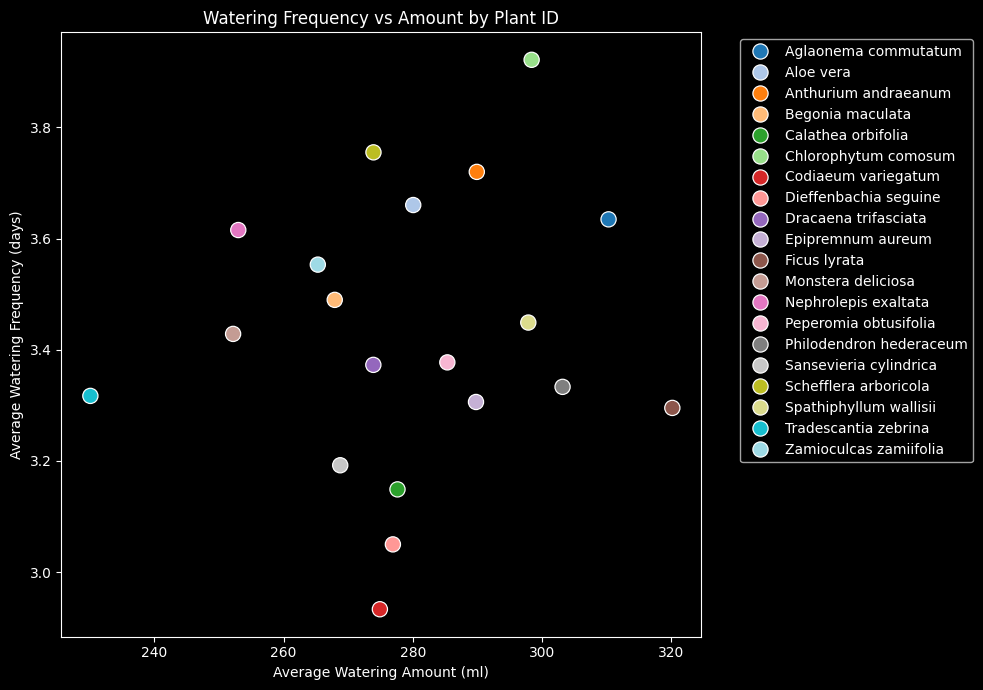

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=plant_water_summary["Watering_Amount_ml"],
    y=plant_water_summary["Watering_Frequency_days"],
    hue=plant_water_summary["Plant_ID"],
    palette="tab20",
    s=120,
    legend="full"
)

plt.title("Watering Frequency vs Amount by Plant ID")
plt.xlabel("Average Watering Amount (ml)")
plt.ylabel("Average Watering Frequency (days)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



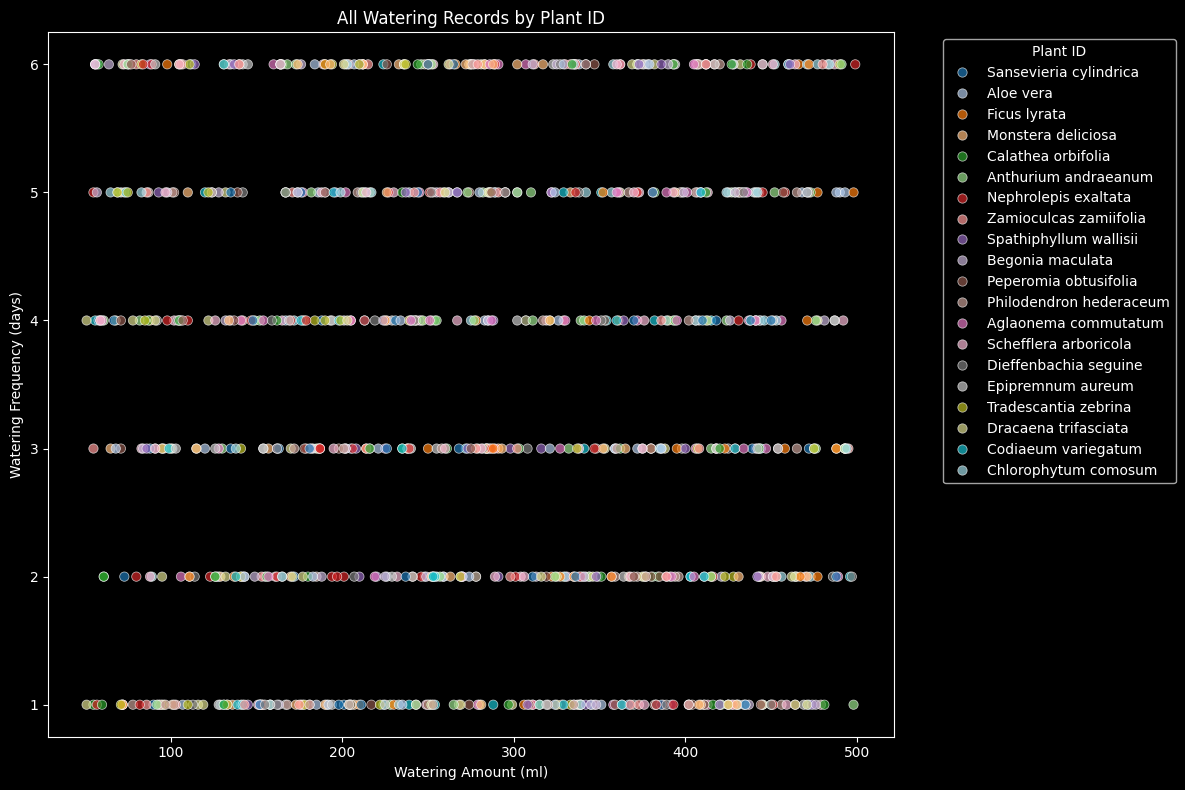

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_clean,
    x="Watering_Amount_ml",
    y="Watering_Frequency_days",
    hue="Plant_ID",
    palette="tab20",
    alpha=0.7,
    s=45
)

plt.title("All Watering Records by Plant ID")
plt.xlabel("Watering Amount (ml)")
plt.ylabel("Watering Frequency (days)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Plant ID")
plt.tight_layout()
plt.show()

In [50]:
from sklearn.cluster import KMeans
import pandas as pd

for k in range(3, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(plant_water_scaled)

    print("k =", k)
    print(pd.Series(labels).value_counts().sort_index())
    print()

k = 3
0     5
1    10
2     5
Name: count, dtype: int64

k = 4
0    4
1    6
2    5
3    5
Name: count, dtype: int64

k = 5
0    5
1    5
2    5
3    1
4    4
Name: count, dtype: int64

k = 6
0    4
1    5
2    1
3    5
4    1
5    4
Name: count, dtype: int64



k = 4 looks the most balanced so we can go with that on for now

In [51]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plant_water_summary = df_clean.groupby("Plant_ID").agg({
    "Watering_Amount_ml": "mean",
    "Watering_Frequency_days": "mean"
}).reset_index()

cluster_features = ["Watering_Amount_ml", "Watering_Frequency_days"]

scaler = StandardScaler()
plant_water_scaled = scaler.fit_transform(plant_water_summary[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
plant_water_summary["Water_Group"] = kmeans.fit_predict(plant_water_scaled)

print(plant_water_summary)

                   Plant_ID  Watering_Amount_ml  Watering_Frequency_days  \
0      Aglaonema commutatum          310.326923                 3.634615   
1                 Aloe vera          280.075472                 3.660377   
2      Anthurium andraeanum          289.920000                 3.720000   
3          Begonia maculata          267.918367                 3.489796   
4        Calathea orbifolia          277.638298                 3.148936   
5      Chlorophytum comosum          298.411765                 3.921569   
6       Codiaeum variegatum          274.911111                 2.933333   
7     Dieffenbachia seguine          276.925000                 3.050000   
8      Dracaena trifasciata          273.898305                 3.372881   
9         Epipremnum aureum          289.795918                 3.306122   
10             Ficus lyrata          320.204545                 3.295455   
11       Monstera deliciosa          252.178571                 3.428571   
12     Nephr

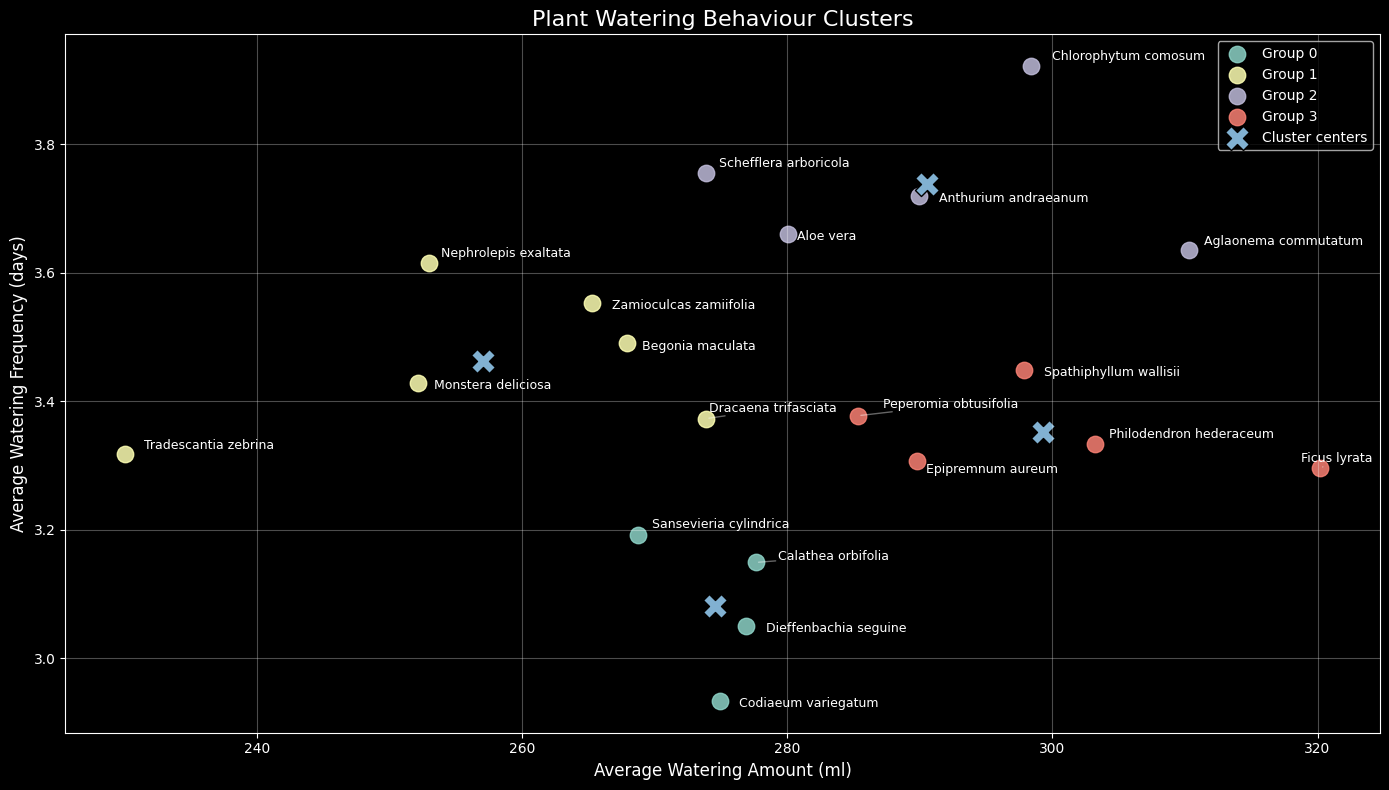

In [52]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plant_water_summary["Short_Name"] = plant_water_summary["Plant_ID"].apply(
    lambda name: " ".join(name.split()[:2])
)

plt.figure(figsize=(14, 8))
texts = []

for group in sorted(plant_water_summary["Water_Group"].unique()):
    group_data = plant_water_summary[plant_water_summary["Water_Group"] == group]

    plt.scatter(
        group_data["Watering_Amount_ml"],
        group_data["Watering_Frequency_days"],
        label=f"Group {group}",
        s=140,
        alpha=0.85
    )

    for _, row in group_data.iterrows():
        texts.append(
            plt.text(
                row["Watering_Amount_ml"],
                row["Watering_Frequency_days"],
                row["Short_Name"],
                fontsize=9
            )
        )

centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=300,
    label="Cluster centers",
    edgecolors="black"
)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", alpha=0.4)
)

plt.xlabel("Average Watering Amount (ml)", fontsize=12)
plt.ylabel("Average Watering Frequency (days)", fontsize=12)
plt.title("Plant Watering Behaviour Clusters", fontsize=16)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

this clustering looks pretty good we have now 4 categories with diferent watering behaviour. so from 20 diferent plants we have 4 categories

so lets add it to the dataset

In [ ]:
water_group_mapping = plant_water_summary[["Plant_ID", "Water_Group"]]

df_clean = df_clean.merge(
    water_group_mapping,
    on="Plant_ID",
    how="left"
)

print(df_clean[["Plant_ID", "Water_Group"]].head(20))
print(df_clean["Water_Group"].value_counts().sort_index())

looks that its quite okay distribution

In [ ]:
print("Missing Water_Group:", df_clean["Water_Group"].isnull().sum())

no failed mapping... perfect

In [ ]:
df_model = df_clean.drop(columns=["Plant_ID"])
df_model

In [ ]:
print(df_model.info())
print(df_model.isnull().sum())

In [ ]:
print(df_model.describe())

In [ ]:
print(df_model["Water_Group"].value_counts().sort_index())
print(df_model["Water_Group"].unique())

In [ ]:
correlations = df_model.corr(numeric_only=True)["Watering_Amount_ml"].sort_values(ascending=False)
print(correlations)

In [ ]:
print("Duplicate rows:", df_model.duplicated().sum())